# Notebook 03 — Baselines y Definición del Protocolo Experimental

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

## Objetivo

Se establecen los modelos de referencia, osea los baselines contra los cuales se evalúa el desempeño del modelo principal. Además define y serializa el split experimental que TODOS los notebooks subsiguientes deben usar.

## Estructura

1. Definición del holdout split, en este caso 5 sujetos y será una semilla fija, y se guarda en models/holdout_split.json para reuso por los notebooks 04 y el 08.
2. Función de evaluación reusable:  Cross-validation con GroupKFold (con k=5) sumado a bootstrap CI 95% sobre métricas.
3. Baseline 1 — Dummy: DummyClassifier(strategy='stratified') y most_frequent. esta establece el piso del azar.
4. Baseline 2 — Heurístico ERP: regresión logística L2 con solo 2 features (amplitud media en AF7 y AF8 en la ventana N400).
5. Comparación y visualización

## Salidas

- `models/holdout_split.json` : sujetos de holdout y de CV.
- `reports/03_baselines_results.csv` : métricas comparativas con CI 95%.
- `figures/03_baselines_confusion_matrices.png` : matrices de confusión.
- `figures/03_baselines_comparison.png` : comparación visual de macro F1.

## 1. Setup

In [2]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
FORCE_RERUN = True

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
FORCE_RERUN:        True


## 2. Instalación + reinicio (saltar `os.kill` en el segundo pase)

In [3]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [4]:
import os
import sys
import json
import yaml
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

print(f'Python:       {sys.version.split()[0]}')
print(f'NumPy:        {np.__version__}')
print(f'scikit-learn: {__import__("sklearn").__version__}')

Python:       3.12.13
NumPy:        2.0.2
scikit-learn: 1.6.1


## 4. Drive y configuración

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f' Config cargada [seed = {SEED}]')
print(f' MODELS_DIR: {MODELS_DIR}')

Mounted at /content/drive
 Config cargada [seed = 42]
 MODELS_DIR: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/models


## 5. Cargar la matriz de features del Notebook 02

In [6]:
features_path = FEATURES_DIR / '02_features_matrix.csv'
assert features_path.exists(), 'No existe la matriz de features.'

df = pd.read_csv(features_path)
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

print(f'  Matriz cargada: {len(df)} epochs × {len(feature_cols)} features')
print(f'  Sujetos: {df["subject_id"].nunique()}')
print(f'  Distribución de clases: {df["label"].value_counts().to_dict()}')

# Verificar que no hay NaN/inf
X_check = df[feature_cols].replace([np.inf, -np.inf], np.nan)
n_nan = X_check.isna().sum().sum()
print(f'  Valores NaN/inf totales: {n_nan}')
if n_nan > 0:
    print(' Hay NaN/inf.')

  Matriz cargada: 1503 epochs × 72 features
  Sujetos: 29
  Distribución de clases: {0: 865, 1: 638}
  Valores NaN/inf totales: 0


## 6.  Definición y serialización del holdout split

Nos ayuda a prevenir leakage. Definimos solamente una vez los 5 sujetos de holdout (con semilla fija), los guardamos en disco, y todos los notebooks subsiguientes lo leerán a partir de aquí.

In [7]:
split_path = MODELS_DIR / 'holdout_split.json'

if split_path.exists() and not FORCE_RERUN:
    print(f' Split ya definido. Cargando desde {split_path}')
    with open(split_path, 'r') as f:
        split_info = json.load(f)
else:
    n_holdout = CFG['splits']['n_holdout_subjects']
    all_subjects = sorted(df['subject_id'].unique())

    rng = np.random.default_rng(SEED)
    holdout_subjects = sorted(rng.choice(all_subjects, size=n_holdout, replace=False).tolist())
    cv_subjects = sorted([s for s in all_subjects if s not in holdout_subjects])

    split_info = {
        'seed': SEED,
        'n_total_subjects':   len(all_subjects),
        'n_cv_subjects':      len(cv_subjects),
        'n_holdout_subjects': len(holdout_subjects),
        'all_subjects':       all_subjects,
        'cv_subjects':        cv_subjects,
        'holdout_subjects':   holdout_subjects,
    }
    with open(split_path, 'w') as f:
        json.dump(split_info, f, indent=2)
    print(f' Split definido y guardado en {split_path}')

print(f'\nTotal de sujetos:   {split_info["n_total_subjects"]}')
print(f'CV (entrenamiento): {split_info["n_cv_subjects"]} sujetos')
print(f'Holdout (test):     {split_info["n_holdout_subjects"]} sujetos')
print(f'\nSujetos de holdout: {split_info["holdout_subjects"]}')
print(f'Sujetos de CV:      {split_info["cv_subjects"]}')

 Split definido y guardado en /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/models/holdout_split.json

Total de sujetos:   29
CV (entrenamiento): 24 sujetos
Holdout (test):     5 sujetos

Sujetos de holdout: ['mu05erp', 'mu17erp', 'mu24erp', 'mu27erp', 'mu36erp']
Sujetos de CV:      ['mu02erp', 'mu04erp', 'mu07erp', 'mu08erp', 'mu10erp', 'mu11erp', 'mu12erp', 'mu13erp', 'mu14erp', 'mu15erp', 'mu16erp', 'mu18erp', 'mu19erp', 'mu20erp', 'mu23erp', 'mu25erp', 'mu26erp', 'mu28erp', 'mu29erp', 'mu30erp', 'mu32erp', 'mu33erp', 'mu34erp', 'mu35erp']


In [8]:
# Construir el dataset de CV (excluye los 5 sujetos de holdout)
df_cv = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)

X_cv = df_cv[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_cv = df_cv['label'].values
groups_cv = df_cv['subject_id'].values

print(f'Dataset de CV:')
print(f'  Forma X: {X_cv.shape}')
print(f'  Forma y: {y_cv.shape}')
print(f'  Sujetos únicos: {len(np.unique(groups_cv))}')
print(f'  Distribución de clases: match={sum(y_cv==0)}  mismatch={sum(y_cv==1)}')
print(f'  Proporción mismatch: {100*sum(y_cv==1)/len(y_cv):.1f}%')

Dataset de CV:
  Forma X: (1238, 72)
  Forma y: (1238,)
  Sujetos únicos: 24
  Distribución de clases: match=709  mismatch=529
  Proporción mismatch: 42.7%


## 7. Verificación anti-leakage

Aquí hacemos un test para probar que ningún sujeto del holdout aparece en df_cv.

In [9]:
cv_subjects_in_df    = set(df_cv['subject_id'].unique())
holdout_subjects_set = set(split_info['holdout_subjects'])

intersection = cv_subjects_in_df & holdout_subjects_set
assert len(intersection) == 0, f'Se detectó leakage: Sujetos en ambos sets: {intersection}'
print(' No se detectó leakage: Ningún sujeto está en ambos sets.')
print(f'   Sujetos en CV:      {len(cv_subjects_in_df)}')
print(f'   Sujetos en holdout: {len(holdout_subjects_set)}')
print(f'   Intersección:       {len(intersection)}')

 No se detectó leakage: Ningún sujeto está en ambos sets.
   Sujetos en CV:      24
   Sujetos en holdout: 5
   Intersección:       0


## 8. Función de evaluación reusable

Esta función se va a usar en todos los notebooks. Toma un pipeline de sklearn y devuelve métricas completas con intervalos de confianza por bootstrap.

El StandardScaler se incluye dentro del pipeline y se ajusta solo en el fold de entrenamiento de cada iteración de CV. Esto para prevenir leakage de información de validación.

In [10]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, ci=0.95, seed=SEED):
    """Bootstrap CI de una métrica."""
    n = len(y_true)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    lo = float(np.percentile(scores, (1 - ci) / 2 * 100))
    hi = float(np.percentile(scores, (1 + ci) / 2 * 100))
    return float(np.mean(scores)), lo, hi


def evaluate_cv(pipeline, X, y, groups, cv_n_splits=5, name='model'):
    """
    Cross-validation con GroupKFold + métricas completas + bootstrap CI.
    """
    gkf = GroupKFold(n_splits=cv_n_splits)

    # Predicciones cross-validated (cada predicción viene de un fold donde el sujeto no se vio en train)
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf)

    # Probabilidades si el modelo lo soporta
    try:
        y_proba = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]
    except (AttributeError, ValueError):
        y_proba = None

    # Métricas con CI bootstrap
    n_boot = CFG['metrics']['bootstrap_n_iterations']

    acc_m, acc_lo, acc_hi = bootstrap_ci(y, y_pred, lambda a, b: accuracy_score(a, b), n_iter=n_boot)
    f1m_m, f1m_lo, f1m_hi = bootstrap_ci(y, y_pred, lambda a, b: f1_score(a, b, average='macro'), n_iter=n_boot)
    pre_m, pre_lo, pre_hi = bootstrap_ci(y, y_pred, lambda a, b: precision_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
    rec_m, rec_lo, rec_hi = bootstrap_ci(y, y_pred, lambda a, b: recall_score(a, b, average='macro', zero_division=0), n_iter=n_boot)

    if y_proba is not None:
        auc_m, auc_lo, auc_hi = bootstrap_ci(y, y_proba, lambda a, b: roc_auc_score(a, b), n_iter=n_boot)
    else:
        auc_m = auc_lo = auc_hi = np.nan

    return {
        'name': name,
        'accuracy':        acc_m,  'accuracy_lo':  acc_lo, 'accuracy_hi':  acc_hi,
        'f1_macro':        f1m_m,  'f1_macro_lo':  f1m_lo, 'f1_macro_hi':  f1m_hi,
        'precision_macro': pre_m,  'precision_lo': pre_lo, 'precision_hi': pre_hi,
        'recall_macro':    rec_m,  'recall_lo':    rec_lo, 'recall_hi':    rec_hi,
        'roc_auc':         auc_m,  'roc_auc_lo':   auc_lo, 'roc_auc_hi':   auc_hi,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'y_true':  y,
    }

print(' Funciones de evaluación definidas')

 Funciones de evaluación definidas


## 9. Baseline 1:  Dummy (azar estructurado)

Predice respetando la distribución de clases observada en entrenamiento (stratified) o siempre la clase mayoritaria (most_frequent). Se establece el piso de azar.

In [11]:
# Dummy stratified
dummy_strat = DummyClassifier(strategy='stratified', random_state=SEED)
results_dummy_strat = evaluate_cv(
    pipeline=dummy_strat,
    X=X_cv, y=y_cv, groups=groups_cv,
    cv_n_splits=CFG['splits']['cv_n_splits'],
    name='Dummy (stratified)'
)
print(f'\n=== {results_dummy_strat["name"]} ===')
print(f'  Accuracy:  {results_dummy_strat["accuracy"]:.3f}  [{results_dummy_strat["accuracy_lo"]:.3f}, {results_dummy_strat["accuracy_hi"]:.3f}]')
print(f'  Macro F1:  {results_dummy_strat["f1_macro"]:.3f}  [{results_dummy_strat["f1_macro_lo"]:.3f}, {results_dummy_strat["f1_macro_hi"]:.3f}]')
print(f'  ROC-AUC:   {results_dummy_strat["roc_auc"]:.3f}  [{results_dummy_strat["roc_auc_lo"]:.3f}, {results_dummy_strat["roc_auc_hi"]:.3f}]')


=== Dummy (stratified) ===
  Accuracy:  0.509  [0.482, 0.538]
  Macro F1:  0.498  [0.472, 0.527]
  ROC-AUC:   0.498  [0.472, 0.527]


In [12]:
# Dummy most_frequent (siempre predice la clase mayoritaria)
dummy_freq = DummyClassifier(strategy='most_frequent', random_state=SEED)
results_dummy_freq = evaluate_cv(
    pipeline=dummy_freq,
    X=X_cv, y=y_cv, groups=groups_cv,
    cv_n_splits=CFG['splits']['cv_n_splits'],
    name='Dummy (most_frequent)'
)
print(f'\n=== {results_dummy_freq["name"]} ===')
print(f'  Accuracy:  {results_dummy_freq["accuracy"]:.3f}  [{results_dummy_freq["accuracy_lo"]:.3f}, {results_dummy_freq["accuracy_hi"]:.3f}]')
print(f'  Macro F1:  {results_dummy_freq["f1_macro"]:.3f}  [{results_dummy_freq["f1_macro_lo"]:.3f}, {results_dummy_freq["f1_macro_hi"]:.3f}]')
print(f'  ROC-AUC:   {results_dummy_freq["roc_auc"]:.3f}  (siempre predice clase mayoritaria, AUC indefinido)')


=== Dummy (most_frequent) ===
  Accuracy:  0.572  [0.544, 0.600]
  Macro F1:  0.364  [0.352, 0.375]
  ROC-AUC:   0.500  (siempre predice clase mayoritaria, AUC indefinido)


## 10. Baseline 2:  Heurístico ERP

Regresión logística con regularización L2 entrenada solo sobre las dos features de amplitud media en la ventana N400: temp_mean_AF7_N400 y temp_mean_AF8_N400.

Esto representa el análisis ERP clásico cuantificado. Si el modelo principal no supera este baseline, la ingeniería de features adicional no aporta valor realmente.

In [13]:
erp_features = ['temp_mean_AF7_N400', 'temp_mean_AF8_N400']
assert all(f in feature_cols for f in erp_features), f'Features no encontradas en df: {erp_features}'

X_erp = df_cv[erp_features].values
print(f'Baseline 2: usando solo {len(erp_features)} features:')
for f in erp_features:
    print(f'  - {f}')
print(f'\nForma de X_erp: {X_erp.shape}')

erp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',   # importante: dataset desbalanceado
        max_iter=2000,
        random_state=SEED
    ))
])

results_erp = evaluate_cv(
    pipeline=erp_pipeline,
    X=X_erp, y=y_cv, groups=groups_cv,
    cv_n_splits=CFG['splits']['cv_n_splits'],
    name='Heurístico ERP [LogReg, 2 features]'
)
print(f'\n=== {results_erp["name"]} ===')
print(f'  Accuracy:  {results_erp["accuracy"]:.3f}  [{results_erp["accuracy_lo"]:.3f}, {results_erp["accuracy_hi"]:.3f}]')
print(f'  Macro F1:  {results_erp["f1_macro"]:.3f}  [{results_erp["f1_macro_lo"]:.3f}, {results_erp["f1_macro_hi"]:.3f}]')
print(f'  Precision: {results_erp["precision_macro"]:.3f}  [{results_erp["precision_lo"]:.3f}, {results_erp["precision_hi"]:.3f}]')
print(f'  Recall:    {results_erp["recall_macro"]:.3f}  [{results_erp["recall_lo"]:.3f}, {results_erp["recall_hi"]:.3f}]')
print(f'  ROC-AUC:   {results_erp["roc_auc"]:.3f}  [{results_erp["roc_auc_lo"]:.3f}, {results_erp["roc_auc_hi"]:.3f}]')

Baseline 2: usando solo 2 features:
  - temp_mean_AF7_N400
  - temp_mean_AF8_N400

Forma de X_erp: (1238, 2)

=== Heurístico ERP [LogReg, 2 features] ===
  Accuracy:  0.502  [0.474, 0.531]
  Macro F1:  0.501  [0.473, 0.529]
  Precision: 0.506  [0.478, 0.534]
  Recall:    0.506  [0.478, 0.535]
  ROC-AUC:   0.506  [0.472, 0.540]


## 11. Baseline 3 Adicional: Heurístico ERP extendido

Es la misma idea pero usando las 4 features ERP.   
La amplitud media de ambos canales, en ambas ventanas. Esto para entender si extender más allá de la ventana N400 ayuda.

In [14]:
erp_ext_features = ['temp_mean_AF7_N400', 'temp_mean_AF8_N400',
                    'temp_mean_AF7_full', 'temp_mean_AF8_full']
X_erp_ext = df_cv[erp_ext_features].values

erp_ext_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                               max_iter=2000, random_state=SEED))
])

results_erp_ext = evaluate_cv(
    pipeline=erp_ext_pipeline,
    X=X_erp_ext, y=y_cv, groups=groups_cv,
    cv_n_splits=CFG['splits']['cv_n_splits'],
    name='Heurístico ERP extendido (De las 4 features)'
)
print(f'\n=== {results_erp_ext["name"]} ===')
print(f'  Accuracy:  {results_erp_ext["accuracy"]:.3f}  [{results_erp_ext["accuracy_lo"]:.3f}, {results_erp_ext["accuracy_hi"]:.3f}]')
print(f'  Macro F1:  {results_erp_ext["f1_macro"]:.3f}  [{results_erp_ext["f1_macro_lo"]:.3f}, {results_erp_ext["f1_macro_hi"]:.3f}]')
print(f'  ROC-AUC:   {results_erp_ext["roc_auc"]:.3f}  [{results_erp_ext["roc_auc_lo"]:.3f}, {results_erp_ext["roc_auc_hi"]:.3f}]')


=== Heurístico ERP extendido (De las 4 features) ===
  Accuracy:  0.519  [0.491, 0.546]
  Macro F1:  0.516  [0.487, 0.542]
  ROC-AUC:   0.512  [0.481, 0.546]


## 12. Tabla comparativa

Resumen consolidado de todos los baselines con sus intervalos de confianza.

In [15]:
all_results = [results_dummy_strat, results_dummy_freq, results_erp, results_erp_ext]

summary_rows = []
for r in all_results:
    summary_rows.append({
        'modelo':    r['name'],
        'accuracy':  f'{r["accuracy"]:.3f}',
        'accuracy_CI95': f'[{r["accuracy_lo"]:.3f}, {r["accuracy_hi"]:.3f}]',
        'macro_F1':  f'{r["f1_macro"]:.3f}',
        'macro_F1_CI95': f'[{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]',
        'roc_auc':   f'{r["roc_auc"]:.3f}' if not np.isnan(r['roc_auc']) else 'N/A',
        'roc_auc_CI95':  f'[{r["roc_auc_lo"]:.3f}, {r["roc_auc_hi"]:.3f}]' if not np.isnan(r['roc_auc']) else 'N/A',
    })

df_summary = pd.DataFrame(summary_rows)
print('=== TABLA COMPARATIVA DE BASELINES (CV con GroupKFold k=5, CI 95% bootstrap) ===\n')
print(df_summary.to_string(index=False))

# Guardar versión numérica
numeric_rows = []
for r in all_results:
    numeric_rows.append({
        'modelo':           r['name'],
        'accuracy':         r['accuracy'],
        'accuracy_lo':      r['accuracy_lo'],
        'accuracy_hi':      r['accuracy_hi'],
        'f1_macro':         r['f1_macro'],
        'f1_macro_lo':      r['f1_macro_lo'],
        'f1_macro_hi':      r['f1_macro_hi'],
        'precision_macro':  r['precision_macro'],
        'recall_macro':     r['recall_macro'],
        'roc_auc':          r['roc_auc'],
        'roc_auc_lo':       r['roc_auc_lo'],
        'roc_auc_hi':       r['roc_auc_hi'],
    })
pd.DataFrame(numeric_rows).to_csv(REPORTS_DIR / '03_baselines_results.csv', index=False)
print(f'\n Guardado: reports/03_baselines_results.csv')

=== TABLA COMPARATIVA DE BASELINES (CV con GroupKFold k=5, CI 95% bootstrap) ===

                                      modelo accuracy  accuracy_CI95 macro_F1  macro_F1_CI95 roc_auc   roc_auc_CI95
                          Dummy (stratified)    0.509 [0.482, 0.538]    0.498 [0.472, 0.527]   0.498 [0.472, 0.527]
                       Dummy (most_frequent)    0.572 [0.544, 0.600]    0.364 [0.352, 0.375]   0.500 [0.500, 0.500]
         Heurístico ERP [LogReg, 2 features]    0.502 [0.474, 0.531]    0.501 [0.473, 0.529]   0.506 [0.472, 0.540]
Heurístico ERP extendido (De las 4 features)    0.519 [0.491, 0.546]    0.516 [0.487, 0.542]   0.512 [0.481, 0.546]

 Guardado: reports/03_baselines_results.csv


## 13. Matrices de confusión

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/03_baselines_confusion_matrices.png


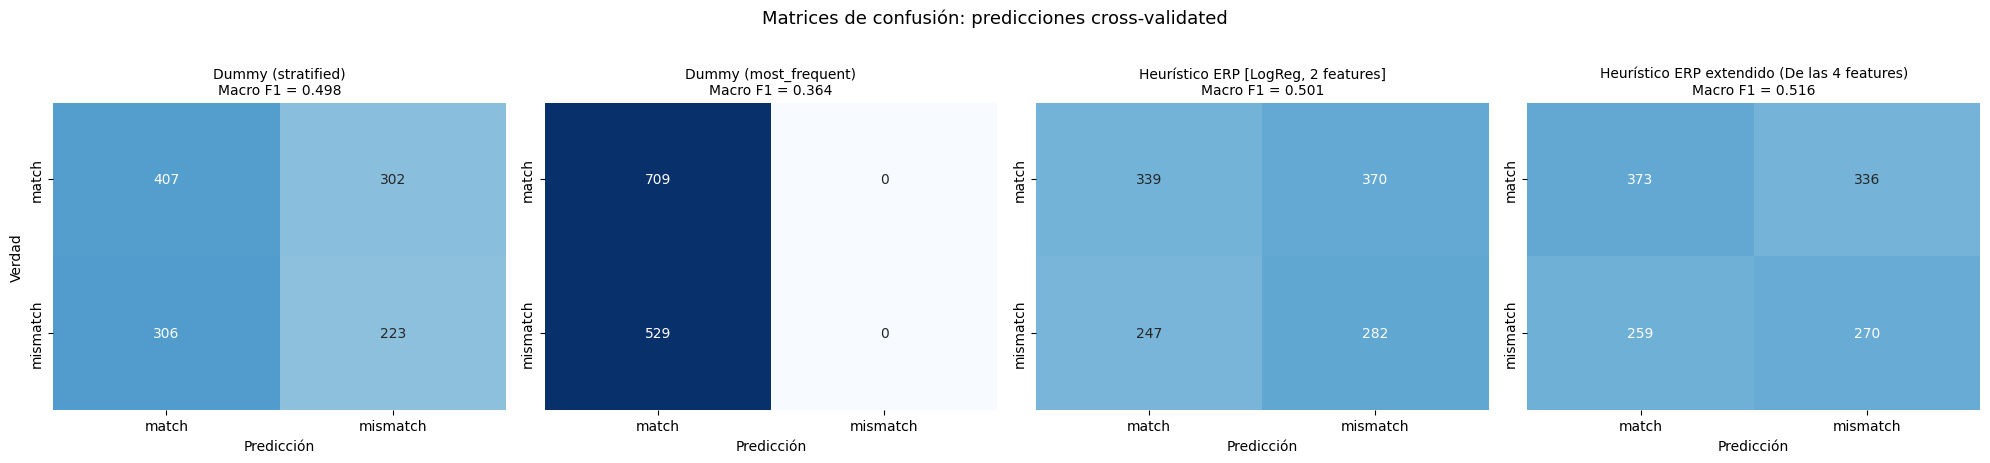

In [16]:
fig, axes = plt.subplots(1, len(all_results), figsize=(5 * len(all_results), 4.5))
if len(all_results) == 1:
    axes = [axes]

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['match', 'mismatch'], yticklabels=['match', 'mismatch'],
                ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdad' if ax is axes[0] else '')
    ax.set_title(f'{r["name"]}\nMacro F1 = {r["f1_macro"]:.3f}', fontsize=10)

plt.suptitle('Matrices de confusión: predicciones cross-validated', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / '03_baselines_confusion_matrices.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 14. Comparación visual de Macro F1 con CI

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/03_baselines_comparison.png


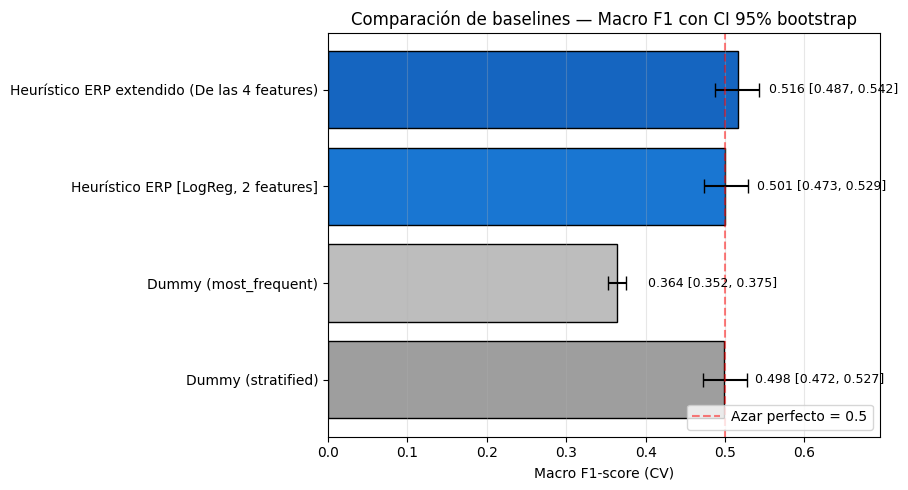

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

names  = [r['name'] for r in all_results]
means  = [r['f1_macro'] for r in all_results]
lo_err = [r['f1_macro'] - r['f1_macro_lo'] for r in all_results]
hi_err = [r['f1_macro_hi'] - r['f1_macro'] for r in all_results]

colors = ['#9e9e9e', '#bdbdbd', '#1976d2', '#1565c0']
bars = ax.barh(names, means, xerr=[lo_err, hi_err], color=colors, capsize=5, edgecolor='black')

# Línea de referencia: F1 macro de azar (~0.5 para clases balanceadas)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Azar perfecto = 0.5')

# Etiquetas con el valor
for i, (bar, m, lo, hi) in enumerate(zip(bars, means, [r['f1_macro_lo'] for r in all_results], [r['f1_macro_hi'] for r in all_results])):
    ax.text(m + max(hi_err) + 0.01, bar.get_y() + bar.get_height()/2,
            f'{m:.3f} [{lo:.3f}, {hi:.3f}]', va='center', fontsize=9)

ax.set_xlabel('Macro F1-score (CV)')
ax.set_xlim(0, max(means) + max(hi_err) + 0.15)
ax.set_title('Comparación de baselines — Macro F1 con CI 95% bootstrap', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '03_baselines_comparison.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()